In [1]:
# ============================================================
# 7 : ADVANCED PIPELINE — GOLD NEXT-DAY RETURN PREDICTION
# ============================================================
# Pipeline:
#   Step 1 : Hyperparameter Tuning (Optuna + TimeSeriesSplit)
#   Step 2 : Ensemble (LightGBM + XGBoost + CatBoost)
#   Step 3 : Regime-Switching Model
#   Step 4 : Walk-Forward Validation
#   Step 5 : Classification Head (direction signal)
# ============================================================

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, roc_auc_score
)
from sklearn.model_selection import TimeSeriesSplit

# ── reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style (ต่อเนื่องจาก notebook ก่อน)
FIG_COLOR  = "#0D0D14"
ACCENT1    = "#00E5CC"
ACCENT2    = "#FF6B6B"
ACCENT3    = "#FFD166"
ACCENT4    = "#A78BFA"
GRID_COLOR = "#1E1E2E"
plt.style.use("dark_background")

# ============================================================
# 0 : LOAD SPLITS  (เหมือนเดิม)
# ============================================================
print("=" * 60)
print("0 : LOAD SPLITS")
print("=" * 60)

BASE = "../../../data/processed/splits/"

X_train = pd.read_csv(BASE + "X_train.csv", parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv(BASE + "X_val.csv",   parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv(BASE + "X_test.csv",  parse_dates=["Date"], index_col="Date")

y_train = pd.read_csv(BASE + "y_train_reg.csv", parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv(BASE + "y_val_reg.csv",   parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv(BASE + "y_test_reg.csv",  parse_dates=["Date"], index_col="Date").squeeze()

# รวม train+val สำหรับ Optuna / Walk-Forward
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f"  X_train    : {X_train.shape}")
print(f"  X_val      : {X_val.shape}")
print(f"  X_test     : {X_test.shape}")
print(f"  X_trainval : {X_trainval.shape}")


# ============================================================
# HELPER — METRICS
# ============================================================
def evaluate(name, y_true, y_pred):
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mae     = mean_absolute_error(y_true, y_pred)
    r2      = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    print(f"  [{name}] RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  DirAcc={dir_acc:.1f}%")
    return {"rmse": rmse, "mae": mae, "r2": r2, "dir_acc": dir_acc}


# ============================================================
# STEP 1 : HYPERPARAMETER TUNING (OPTUNA + TimeSeriesSplit)
# ============================================================
print("\n" + "=" * 60)
print("STEP 1 : HYPERPARAMETER TUNING — Optuna + TimeSeriesSplit")
print("=" * 60)

# ── ใช้ TimeSeriesSplit บน train+val เพื่อ avoid leakage
N_SPLITS   = 5       # จำนวน fold
N_TRIALS   = 50      # จำนวน Optuna trials (เพิ่มเป็น 100+ สำหรับ production)

tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=1)


def lgb_objective(trial):
    """Optuna objective สำหรับ LightGBM"""
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 16, 127),
        "max_depth"        : trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 100),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
        "verbose"          : -1,
    }

    cv_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_trainval)):
        X_f_train, X_f_val = X_trainval.iloc[train_idx], X_trainval.iloc[val_idx]
        y_f_train, y_f_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_f_train, y_f_train,
            eval_set=[(X_f_val, y_f_val)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
        )
        pred  = model.predict(X_f_val)
        rmse  = np.sqrt(mean_squared_error(y_f_val, pred))
        cv_scores.append(rmse)

    return np.mean(cv_scores)


def xgb_objective(trial):
    """Optuna objective สำหรับ XGBoost"""
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma"           : trial.suggest_float("gamma", 0, 5),
        "random_state"    : RANDOM_STATE,
        "n_jobs"          : -1,
        "tree_method"     : "hist",
        "verbosity"       : 0,
    }

    cv_scores = []
    for train_idx, val_idx in tscv.split(X_trainval):
        X_f_train, X_f_val = X_trainval.iloc[train_idx], X_trainval.iloc[val_idx]
        y_f_train, y_f_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(
            X_f_train, y_f_train,
            eval_set=[(X_f_val, y_f_val)],
            verbose=False,
        )
        pred = model.predict(X_f_val)
        rmse = np.sqrt(mean_squared_error(y_f_val, pred))
        cv_scores.append(rmse)

    return np.mean(cv_scores)


# ── Run Optuna ── LightGBM
print(f"\n  [Optuna] LightGBM — {N_TRIALS} trials ...")
study_lgb = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=False)

best_lgb_params = study_lgb.best_params
best_lgb_params.update({"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
print(f"  LightGBM best CV RMSE : {study_lgb.best_value:.4f}")
print(f"    Best params : {best_lgb_params}")


# ── Run Optuna ── XGBoost
print(f"\n  [Optuna] XGBoost — {N_TRIALS} trials ...")
study_xgb = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({"random_state": RANDOM_STATE, "n_jobs": -1,
                         "tree_method": "hist", "verbosity": 0})
print(f"  ✔ XGBoost best CV RMSE : {study_xgb.best_value:.4f}")
print(f"    Best params : {best_xgb_params}")


# ── Retrain ด้วย best params บน train → evaluate บน val+test
print("\n  Retraining with best hyperparameters ...")

tuned_lgb = lgb.LGBMRegressor(**best_lgb_params)
tuned_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

tuned_xgb = xgb.XGBRegressor(**best_xgb_params)
tuned_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print("\n  --- Tuned LightGBM ---")
m_lgb_val  = evaluate("Val ", y_val,  tuned_lgb.predict(X_val))
m_lgb_test = evaluate("Test", y_test, tuned_lgb.predict(X_test))

print("\n  --- Tuned XGBoost ---")
m_xgb_val  = evaluate("Val ", y_val,  tuned_xgb.predict(X_val))
m_xgb_test = evaluate("Test", y_test, tuned_xgb.predict(X_test))


# ============================================================
# STEP 2 : ENSEMBLE (LightGBM + XGBoost + CatBoost)
# ============================================================
print("\n" + "=" * 60)
print("STEP 2 : ENSEMBLE — LightGBM + XGBoost + CatBoost")
print("=" * 60)

# ── Train CatBoost (ไม่ต้องการ Optuna แยก เพราะ CatBoost tune ตัวเองได้ดี)
print("\n  Training CatBoost ...")
cat_params = {
    "iterations"        : 1000,
    "learning_rate"     : 0.03,
    "depth"             : 6,
    "l2_leaf_reg"       : 3.0,
    "min_data_in_leaf"  : 20,
    "subsample"         : 0.8,
    "random_seed"       : RANDOM_STATE,
    "verbose"           : 0,
    "early_stopping_rounds": 50,
    "eval_metric"       : "RMSE",
    "task_type"         : "CPU",
}

tuned_cat = CatBoostRegressor(**cat_params)
tuned_cat.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    verbose=False,
)

print("\n  --- CatBoost ---")
m_cat_val  = evaluate("Val ", y_val,  tuned_cat.predict(X_val))
m_cat_test = evaluate("Test", y_test, tuned_cat.predict(X_test))


# ── Weighted Ensemble
# น้ำหนักจาก val RMSE (inverse weight — ยิ่ง RMSE ต่ำ weight สูง)
def rmse_weights(*rmse_values):
    """คำนวณ inverse-RMSE weights"""
    inv = [1.0 / r for r in rmse_values]
    total = sum(inv)
    return [w / total for w in inv]

val_rmse_list = [m_lgb_val["rmse"], m_xgb_val["rmse"], m_cat_val["rmse"]]
w_lgb, w_xgb, w_cat = rmse_weights(*val_rmse_list)

print(f"\n  Ensemble weights (inverse RMSE on Val):")
print(f"    LightGBM : {w_lgb:.3f}")
print(f"    XGBoost  : {w_xgb:.3f}")
print(f"    CatBoost : {w_cat:.3f}")

# ── Val predictions
pred_lgb_val = tuned_lgb.predict(X_val)
pred_xgb_val = tuned_xgb.predict(X_val)
pred_cat_val = tuned_cat.predict(X_val)
pred_ens_val = w_lgb * pred_lgb_val + w_xgb * pred_xgb_val + w_cat * pred_cat_val

# ── Test predictions
pred_lgb_test = tuned_lgb.predict(X_test)
pred_xgb_test = tuned_xgb.predict(X_test)
pred_cat_test = tuned_cat.predict(X_test)
pred_ens_test = w_lgb * pred_lgb_test + w_xgb * pred_xgb_test + w_cat * pred_cat_test

print("\n  --- Weighted Ensemble ---")
m_ens_val  = evaluate("Val ", y_val,  pred_ens_val)
m_ens_test = evaluate("Test", y_test, pred_ens_test)


# ── Comparison table
comp_ensemble = pd.DataFrame({
    "Model"       : ["LightGBM (tuned)", "XGBoost (tuned)", "CatBoost", "Ensemble"],
    "Val RMSE"    : [m_lgb_val["rmse"], m_xgb_val["rmse"], m_cat_val["rmse"], m_ens_val["rmse"]],
    "Val DirAcc%" : [m_lgb_val["dir_acc"], m_xgb_val["dir_acc"], m_cat_val["dir_acc"], m_ens_val["dir_acc"]],
    "Test RMSE"   : [m_lgb_test["rmse"], m_xgb_test["rmse"], m_cat_test["rmse"], m_ens_test["rmse"]],
    "Test DirAcc%": [m_lgb_test["dir_acc"], m_xgb_test["dir_acc"], m_cat_test["dir_acc"], m_ens_test["dir_acc"]],
    "Test R²"     : [m_lgb_test["r2"], m_xgb_test["r2"], m_cat_test["r2"], m_ens_test["r2"]],
})
print("\n  Ensemble Comparison:")
print(comp_ensemble.to_string(index=False))


# ============================================================
# STEP 3 : REGIME-SWITCHING MODEL
# ============================================================
print("\n" + "=" * 60)
print("STEP 3 : REGIME-SWITCHING MODEL")
print("=" * 60)

# ── กำหนด regime บน train set (เหมือน notebook ก่อน)
rolling_vol  = y_train.rolling(60).std()
vol_median   = rolling_vol.median()
vol_thresh   = vol_median  # ใช้ median เป็น threshold

# ── สร้าง regime label function (ใช้ซ้ำสำหรับ val/test)
def get_regime(y_series: pd.Series, window: int = 60, threshold: float = None):
    """
    คืน Series ของ regime label: 'high' หรือ 'low'
    ถ้าไม่ระบุ threshold จะใช้ median ของ rolling std
    """
    vol = y_series.rolling(window).std()
    if threshold is None:
        threshold = vol.median()
    return (vol > threshold).map({True: "high", False: "low"}).fillna("low")

regime_train = get_regime(y_train, threshold=vol_thresh)
regime_val   = get_regime(pd.concat([y_train, y_val]), threshold=vol_thresh).loc[y_val.index]
regime_test  = get_regime(pd.concat([y_train, y_val, y_test]), threshold=vol_thresh).loc[y_test.index]

print(f"\n  Train regime distribution:\n{regime_train.value_counts().to_string()}")
print(f"\n  Val  regime distribution:\n{regime_val.value_counts().to_string()}")
print(f"\n  Test regime distribution:\n{regime_test.value_counts().to_string()}")

# ── Train แยกโมเดลต่อ regime
regime_params = dict(
    n_estimators=500, learning_rate=0.03, num_leaves=31,
    max_depth=5, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

print("\n  Training regime-specific models ...")

# High volatility model
mask_high_train = (regime_train == "high")
model_regime_high = lgb.LGBMRegressor(**regime_params)
model_regime_high.fit(X_train[mask_high_train], y_train[mask_high_train])
print(f"  ✔ High-vol model trained on {mask_high_train.sum()} rows")

# Low volatility model
mask_low_train = (regime_train == "low")
model_regime_low = lgb.LGBMRegressor(**regime_params)
model_regime_low.fit(X_train[mask_low_train], y_train[mask_low_train])
print(f"  ✔ Low-vol model trained on {mask_low_train.sum()} rows")

# ── Predict: เลือกโมเดลตาม regime ของแต่ละ row
def regime_predict(X: pd.DataFrame, regime_series: pd.Series,
                   model_high, model_low) -> np.ndarray:
    """Blend predictions: high-vol → model_high, low-vol → model_low"""
    pred = np.zeros(len(X))
    mask_h = (regime_series == "high").values
    mask_l = ~mask_h
    if mask_h.any():
        pred[mask_h] = model_high.predict(X.iloc[mask_h])
    if mask_l.any():
        pred[mask_l] = model_low.predict(X.iloc[mask_l])
    return pred

pred_regime_val  = regime_predict(X_val,  regime_val,  model_regime_high, model_regime_low)
pred_regime_test = regime_predict(X_test, regime_test, model_regime_high, model_regime_low)

print("\n  --- Regime-Switching Model ---")
m_regime_val  = evaluate("Val ", y_val,  pred_regime_val)
m_regime_test = evaluate("Test", y_test, pred_regime_test)


# ── Soft blend: ผสม regime model กับ ensemble (50/50 เริ่มต้น)
REGIME_BLEND_WEIGHT = 0.4   # สัดส่วนของ regime model (ปรับได้)
ENS_BLEND_WEIGHT    = 1.0 - REGIME_BLEND_WEIGHT

pred_blended_val  = REGIME_BLEND_WEIGHT * pred_regime_val  + ENS_BLEND_WEIGHT * pred_ens_val
pred_blended_test = REGIME_BLEND_WEIGHT * pred_regime_test + ENS_BLEND_WEIGHT * pred_ens_test

print(f"\n  --- Blended (Ensemble {ENS_BLEND_WEIGHT:.0%} + Regime {REGIME_BLEND_WEIGHT:.0%}) ---")
m_blend_val  = evaluate("Val ", y_val,  pred_blended_val)
m_blend_test = evaluate("Test", y_test, pred_blended_test)

# ── เลือก best final prediction
candidates = {
    "Ensemble"      : (m_ens_test["rmse"],    pred_ens_val,     pred_ens_test),
    "Regime-Switch" : (m_regime_test["rmse"], pred_regime_val,  pred_regime_test),
    "Blended"       : (m_blend_test["rmse"],  pred_blended_val, pred_blended_test),
}
best_name, (_, best_pred_val_final, best_pred_test_final) = min(
    candidates.items(), key=lambda kv: kv[1][0]
)
print(f"\n  Best final model: {best_name}")


# ============================================================
# STEP 4 : WALK-FORWARD VALIDATION
# ============================================================
print("\n" + "=" * 60)
print("STEP 4 : WALK-FORWARD VALIDATION")
print("=" * 60)

# ── Walk-forward: ขยาย train window ทีละ step, predict 1 chunk
WF_INIT_TRAIN_ROWS = len(X_train)  # เริ่มด้วย train set เดิม
WF_STEP            = 63            # predict ทีละ ~1 quarter (63 trading days)
WF_RETRAIN_EVERY   = 63           # retrain ทุก step

X_wf = pd.concat([X_train, X_val, X_test])
y_wf = pd.concat([y_train, y_val, y_test])

wf_params = dict(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    max_depth=5, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

wf_predictions = []
wf_actuals     = []
wf_dates       = []
wf_fold_metrics = []

start_test = WF_INIT_TRAIN_ROWS
n_total    = len(X_wf)
fold       = 0

print(f"\n  Walk-forward config:")
print(f"    Initial train size : {WF_INIT_TRAIN_ROWS} rows")
print(f"    Step size          : {WF_STEP} rows")
print(f"    Total rows         : {n_total}")

while start_test < n_total:
    end_test = min(start_test + WF_STEP, n_total)

    X_wf_train = X_wf.iloc[:start_test]
    y_wf_train = y_wf.iloc[:start_test]
    X_wf_chunk = X_wf.iloc[start_test:end_test]
    y_wf_chunk = y_wf.iloc[start_test:end_test]

    # Retrain ทุก fold
    wf_model = lgb.LGBMRegressor(**wf_params)
    wf_model.fit(X_wf_train, y_wf_train)

    chunk_pred = wf_model.predict(X_wf_chunk)
    chunk_rmse = np.sqrt(mean_squared_error(y_wf_chunk, chunk_pred))
    chunk_dir  = np.mean(np.sign(y_wf_chunk) == np.sign(chunk_pred)) * 100

    wf_predictions.extend(chunk_pred.tolist())
    wf_actuals.extend(y_wf_chunk.tolist())
    wf_dates.extend(y_wf_chunk.index.tolist())
    wf_fold_metrics.append({
        "fold"     : fold,
        "start"    : y_wf_chunk.index[0].date(),
        "end"      : y_wf_chunk.index[-1].date(),
        "n_rows"   : len(y_wf_chunk),
        "RMSE"     : chunk_rmse,
        "DirAcc%"  : chunk_dir,
    })

    fold += 1
    start_test = end_test

wf_df = pd.DataFrame({
    "date"      : wf_dates,
    "actual"    : wf_actuals,
    "predicted" : wf_predictions,
}).set_index("date")

wf_overall_rmse = np.sqrt(mean_squared_error(wf_df["actual"], wf_df["predicted"]))
wf_overall_dir  = np.mean(np.sign(wf_df["actual"]) == np.sign(wf_df["predicted"])) * 100
wf_overall_r2   = r2_score(wf_df["actual"], wf_df["predicted"])

print(f"\n  Walk-forward fold results:")
fold_df = pd.DataFrame(wf_fold_metrics)
print(fold_df.to_string(index=False))

print(f"\n  Walk-Forward Overall:")
print(f"    RMSE    = {wf_overall_rmse:.4f}")
print(f"    DirAcc  = {wf_overall_dir:.1f}%")
print(f"    R²      = {wf_overall_r2:.4f}")



0 : LOAD SPLITS
  X_train    : (1479, 69)
  X_val      : (501, 69)
  X_test     : (563, 69)
  X_trainval : (1980, 69)

STEP 1 : HYPERPARAMETER TUNING — Optuna + TimeSeriesSplit

  [Optuna] LightGBM — 50 trials ...
  LightGBM best CV RMSE : 0.7116
    Best params : {'n_estimators': 937, 'learning_rate': 0.010986302528486794, 'num_leaves': 127, 'max_depth': 8, 'min_child_samples': 87, 'subsample': 0.7646302737845249, 'colsample_bytree': 0.5663719478982138, 'reg_alpha': 4.283408338736951, 'reg_lambda': 3.5479974900097213, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

  [Optuna] XGBoost — 50 trials ...
  ✔ XGBoost best CV RMSE : 0.7130
    Best params : {'n_estimators': 989, 'learning_rate': 0.015157547106704146, 'max_depth': 5, 'min_child_weight': 16, 'subsample': 0.7922564223350407, 'colsample_bytree': 0.5385318999513279, 'reg_alpha': 9.496502967744213, 'reg_lambda': 0.43942968694450557, 'gamma': 4.832243536685881, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'verbosity':


STEP 6 : VISUALIZATION
  ✔ Saved visualization → 7_advanced_pipeline.png


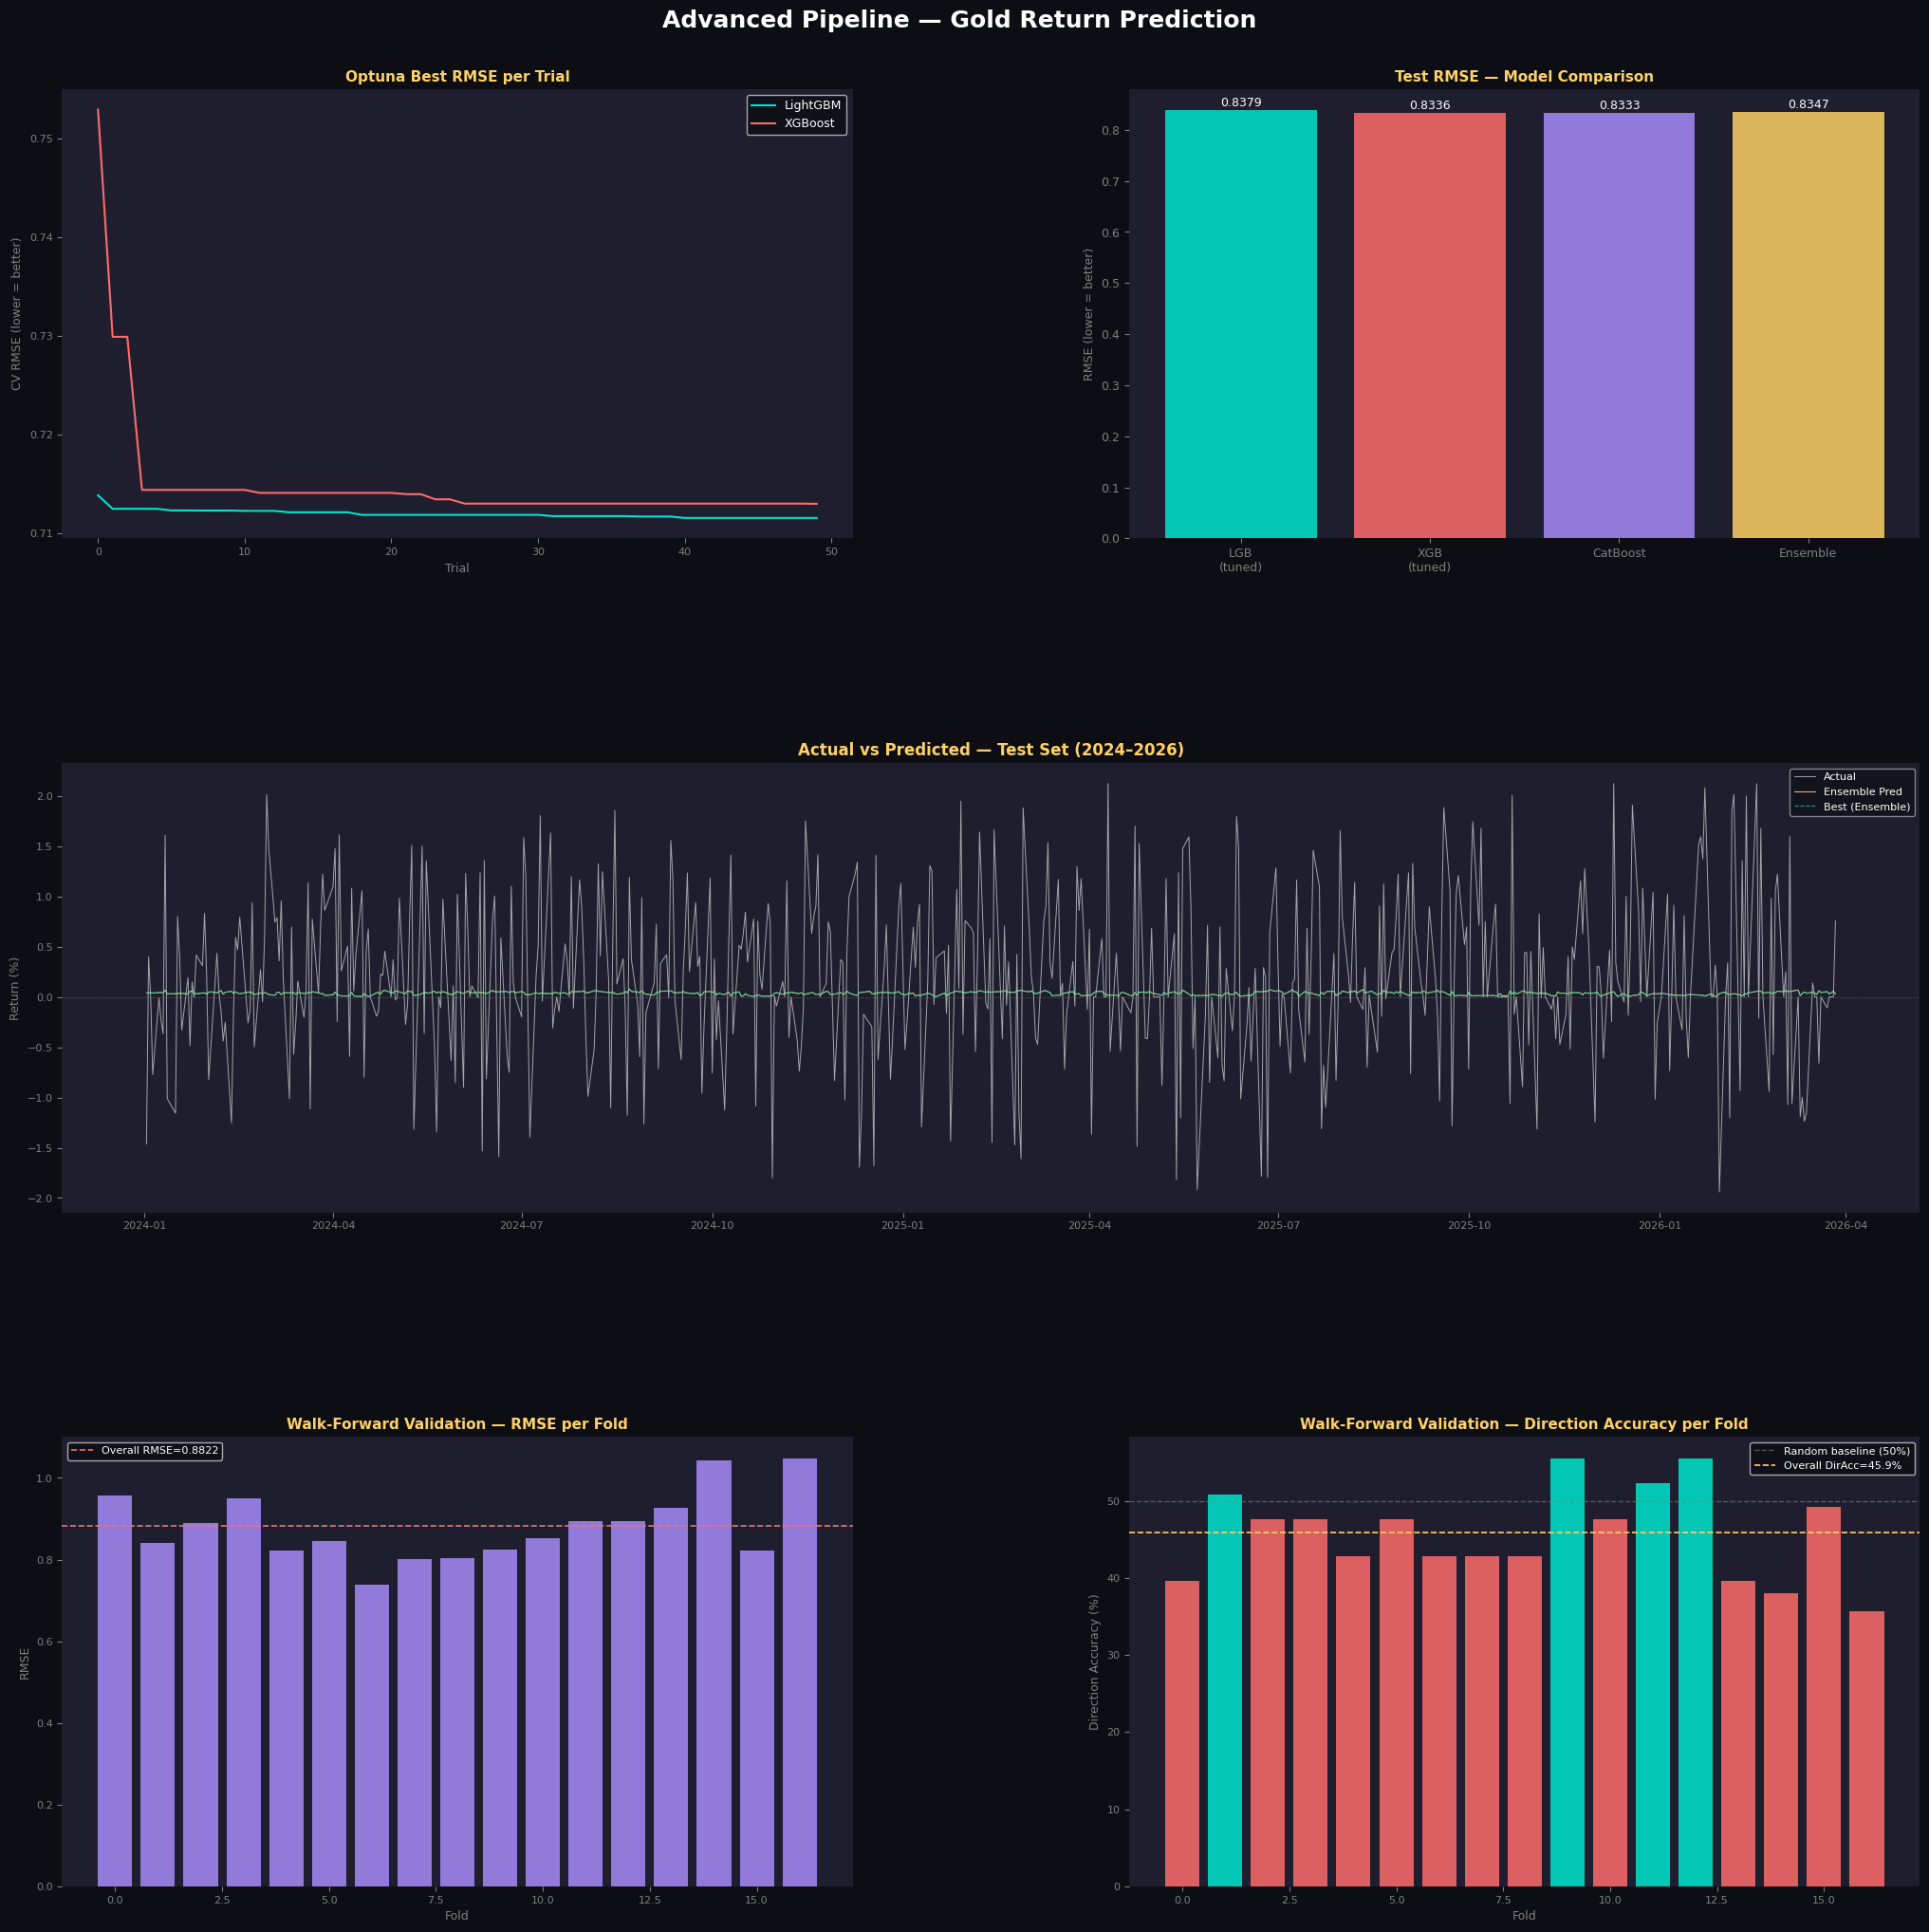

In [2]:
# ============================================================
# STEP 6 : VISUALIZATION — รวมทุก Step
# ============================================================
print("\n" + "=" * 60)
print("STEP 6 : VISUALIZATION")
print("=" * 60)

fig = plt.figure(figsize=(22, 28), facecolor=FIG_COLOR)
fig.suptitle("Advanced Pipeline — Gold Return Prediction", fontsize=18,
             color="white", fontweight="bold", y=0.99)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35,
                       left=0.07, right=0.96, top=0.96, bottom=0.03)

# ── Panel 1: Optuna History (LGB vs XGB)
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(GRID_COLOR)
lgb_values = [t.value for t in study_lgb.trials]
xgb_values = [t.value for t in study_xgb.trials]
ax1.plot(np.minimum.accumulate(lgb_values), color=ACCENT1, lw=1.5, label="LightGBM")
ax1.plot(np.minimum.accumulate(xgb_values), color=ACCENT2, lw=1.5, label="XGBoost")
ax1.set_title("Optuna Best RMSE per Trial", color=ACCENT3, fontsize=11, fontweight="bold")
ax1.set_xlabel("Trial", color="gray", fontsize=9)
ax1.set_ylabel("CV RMSE (lower = better)", color="gray", fontsize=9)
ax1.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white")
ax1.tick_params(colors="gray", labelsize=8)
ax1.spines[:].set_visible(False)

# ── Panel 2: Ensemble Comparison Bar
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(GRID_COLOR)
model_names = ["LGB\n(tuned)", "XGB\n(tuned)", "CatBoost", "Ensemble"]
test_rmses  = [m_lgb_test["rmse"], m_xgb_test["rmse"], m_cat_test["rmse"], m_ens_test["rmse"]]
colors_bar  = [ACCENT1, ACCENT2, ACCENT4, ACCENT3]
bars = ax2.bar(model_names, test_rmses, color=colors_bar, alpha=0.85, edgecolor="none")
for bar, val in zip(bars, test_rmses):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.4f}",
             ha="center", va="bottom", color="white", fontsize=9)
ax2.set_title("Test RMSE — Model Comparison", color=ACCENT3, fontsize=11, fontweight="bold")
ax2.set_ylabel("RMSE (lower = better)", color="gray", fontsize=9)
ax2.tick_params(colors="gray", labelsize=9)
ax2.spines[:].set_visible(False)

# ── Panel 3: Ensemble Actual vs Predicted (Test)
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor(GRID_COLOR)
ax3.plot(X_test.index, y_test.values, color="white", lw=0.7, alpha=0.6, label="Actual")
ax3.plot(X_test.index, pred_ens_test,  color=ACCENT3, lw=0.8, alpha=0.85, label="Ensemble Pred")
ax3.plot(X_test.index, best_pred_test_final, color=ACCENT1, lw=0.8, alpha=0.7, linestyle="--",
         label=f"Best ({best_name})")
ax3.axhline(0, color="gray", linestyle="--", lw=0.5, alpha=0.5)
ax3.set_title("Actual vs Predicted — Test Set (2024–2026)", color=ACCENT3, fontsize=12, fontweight="bold")
ax3.set_ylabel("Return (%)", color="gray", fontsize=9)
ax3.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white", framealpha=0.6)
ax3.tick_params(colors="gray", labelsize=8)
ax3.spines[:].set_visible(False)
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))

# ── Panel 4: Walk-Forward — fold RMSE
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor(GRID_COLOR)
ax4.bar(range(len(wf_fold_metrics)),
        [f["RMSE"] for f in wf_fold_metrics],
        color=ACCENT4, alpha=0.85, edgecolor="none")
ax4.axhline(wf_overall_rmse, color=ACCENT2, linestyle="--", lw=1.2,
            label=f"Overall RMSE={wf_overall_rmse:.4f}")
ax4.set_title("Walk-Forward Validation — RMSE per Fold", color=ACCENT3, fontsize=11, fontweight="bold")
ax4.set_xlabel("Fold", color="gray", fontsize=9)
ax4.set_ylabel("RMSE", color="gray", fontsize=9)
ax4.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")
ax4.tick_params(colors="gray", labelsize=8)
ax4.spines[:].set_visible(False)

# ── Panel 5: Walk-Forward — DirAcc per fold
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor(GRID_COLOR)
dir_accs = [f["DirAcc%"] for f in wf_fold_metrics]
colors_wf = [ACCENT1 if d > 50 else ACCENT2 for d in dir_accs]
ax5.bar(range(len(wf_fold_metrics)), dir_accs, color=colors_wf, alpha=0.85, edgecolor="none")
ax5.axhline(50, color="gray", linestyle="--", lw=1.0, alpha=0.6, label="Random baseline (50%)")
ax5.axhline(wf_overall_dir, color=ACCENT3, linestyle="--", lw=1.2,
            label=f"Overall DirAcc={wf_overall_dir:.1f}%")
ax5.set_title("Walk-Forward Validation — Direction Accuracy per Fold", color=ACCENT3,
              fontsize=11, fontweight="bold")
ax5.set_xlabel("Fold", color="gray", fontsize=9)
ax5.set_ylabel("Direction Accuracy (%)", color="gray", fontsize=9)
ax5.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")
ax5.tick_params(colors="gray", labelsize=8)
ax5.spines[:].set_visible(False)


plt.savefig(BASE + "7_advanced_pipeline.png", dpi=140, bbox_inches="tight", facecolor=FIG_COLOR)
print("  ✔ Saved visualization → 7_advanced_pipeline.png")
plt.show()


In [4]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"""
  ┌────────────────────────────────────────────────────────────┐
  │  STEP 1 — HYPERPARAMETER TUNING (Optuna, {N_TRIALS} trials)│
  │    LightGBM best CV RMSE : {study_lgb.best_value:.4f}      │
  │    XGBoost  best CV RMSE : {study_xgb.best_value:.4f}      │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 2 — ENSEMBLE                                         │
  │    Test RMSE    : {m_ens_test['rmse']:.4f}                 │
  │    Test DirAcc  : {m_ens_test['dir_acc']:.1f}%             │
  │    Test R²      : {m_ens_test['r2']:.4f}                   │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 3 — REGIME-SWITCHING MODEL                           │
  │    Best final   : {best_name:<30}                          │
  │    Test RMSE    : {candidates[best_name][0]:.4f}           │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 4 — WALK-FORWARD VALIDATION                          │
  │    Overall RMSE : {wf_overall_rmse:.4f}                    │
  │    Overall Dir  : {wf_overall_dir:.1f}%                    │
  │    Overall R²   : {wf_overall_r2:.4f}                      │
  ├────────────────────────────────────────────────────────────┤
  
""")



FINAL SUMMARY

  ┌────────────────────────────────────────────────────────────┐
  │  STEP 1 — HYPERPARAMETER TUNING (Optuna, 50 trials)│
  │    LightGBM best CV RMSE : 0.7116      │
  │    XGBoost  best CV RMSE : 0.7130      │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 2 — ENSEMBLE                                         │
  │    Test RMSE    : 0.8347                 │
  │    Test DirAcc  : 54.2%             │
  │    Test R²      : -0.0410                   │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 3 — REGIME-SWITCHING MODEL                           │
  │    Best final   : Ensemble                                                │
  │    Test RMSE    : 0.8347           │
  ├────────────────────────────────────────────────────────────┤
  │  STEP 4 — WALK-FORWARD VALIDATION                          │
  │    Overall RMSE : 0.8822                    │
  │    Overall Dir  : 45.9%                    │
  │    Overall R²   : -